# Pendahuluan

1. Ini adalah lanjutan dari `01_Regresi_Logistik.ipynb`.
2. Tujuannya adalah untuk menerapkan berbagai macam metode lain yang bisa digunakan untuk mengetahui variabel X mana yang berpengaruh kepada Y. Ini digunakan untuk analisis lanjutan lebih lanjut dari hasil sebelumnya.
3. Variabel X (independen) dan Y (dependen):
* Variabel X = Profitabilitas (ROA), Tangibility (TAS), Cash Holding (CRO), Struktur Modal (DTR), Retained Earnings (RNR), Ukuran Perusahaan (LTA)
* Variabel Y = Fleksibilitas Keuangan (FFR)

# Import, Load, dan Preprocessing

In [1]:
# Library olah data default
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams

# Olah statistik
from scipy import stats

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE, RFECV, SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap

In [2]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [3]:
df_fmcg = pd.read_excel('https://drive.google.com/uc?id=1IHnAxLw5kz1QSveCgPCEbPE0FxlYT7jw')

In [4]:
df_fmcg.sample(5)

,Emiten,Tahun,FFR,ROA,TAS,CRO,DTR,RNR,LTA
160,DLTA,2020,1,0.101208,0.064555,0.568896,0.167824,0.001226,14.018926
56,NaN,2021,0,0.053030,0.431865,0.030803,0.487647,0.003750,16.433794
129,NaN,2024,1,0.041611,0.473363,0.154435,0.356004,0.008717,17.433104
68,NaN,2023,0,0.048047,0.200840,0.053237,0.452457,0.002243,16.124826
136,NaN,2021,1,0.061006,0.321698,0.192520,0.369952,0.008262,15.868032


Pemisahan nama-nama kolom untuk variabel X dan juga Y

In [5]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df_fmcg[['ROA', 'TAS', 'CRO', 'DTR', 'RNR', 'LTA']]
Y = df_fmcg['FFR']

Pemisahan data yang merupakan kelas 0 ataupun kelas 1, yang akan dipakai untuk Uji Hipotesis pada Korelasi atau Independent T-Test.

In [6]:
Kelas0 = df_fmcg[df_fmcg['FFR'] == 0]
Kelas1 = df_fmcg[df_fmcg['FFR'] == 1]

print(f"Jumlah data Kelas0 (FFR=0): {len(Kelas0)}")
print(f"Jumlah data Kelas1 (FFR=1): {len(Kelas1)}")

Jumlah data Kelas0 (FFR=0): 105
Jumlah data Kelas1 (FFR=1): 65


Pemisahan data ke data train dan data test, yang akan dipakai untuk machine learning

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

# Uji Asumsi (Prasyarat)

## Uji Normalitas

* Uji Asumsi sebagai persyaratan. Uji pertama yang dilakukan adalah Uji Normalitas pada seluruh Variabel X. Karena banyak data >50, maka menggunakan Kolmogorov-Smirnov. Jika data < 50, maka menggunakan Shapiro-Wilk
* Data harus Normal pada kedua Kelas 0 dan 1. Jika satu saja tidak normal, maka hasil final adalah tidak normal

In [14]:
# Uji Normalitas menggunakan Kolmogorov-Smirnov untuk Kelas0 dan Kelas1
ks_results = []

for col in X.columns:
    # Uji untuk Kelas0
    data0 = Kelas0[col]
    data0_std = (data0 - data0.mean()) / data0.std() if data0.std() != 0 else data0
    stat0, p0 = stats.kstest(data0_std, 'norm')
    is_normal0 = 'Yes' if p0 > 0.05 else 'No'

    # Uji untuk Kelas1
    data1 = Kelas1[col]
    data1_std = (data1 - data1.mean()) / data1.std() if data1.std() != 0 else data1
    stat1, p1 = stats.kstest(data1_std, 'norm')
    is_normal1 = 'Yes' if p1 > 0.05 else 'No'

    # Menentukan Normal-Final
    normal_final = 'Yes' if (is_normal0 == 'Yes' and is_normal1 == 'Yes') else 'No'

    ks_results.append({
        'Variable': col,
        'Stat0': round(stat0, 4),
        'P-Value0': round(p0, 4),
        'Normal0': is_normal0,
        'Stat1': round(stat1, 4),
        'P-Value1': round(p1, 4),
        'Normal1': is_normal1,
        'Normal-Final': normal_final
    })

ks_df = pd.DataFrame(ks_results)
ks_df

,Variable,Stat0,P-Value0,Normal0,Stat1,P-Value1,Normal1,Normal-Final
0,ROA,0.1790,0.0020,No,0.1227,0.2595,Yes,No
1,TAS,0.0874,0.3770,Yes,0.0742,0.8401,Yes,Yes
2,CRO,0.1426,0.0252,No,0.2208,0.0029,No,No
3,DTR,0.0780,0.5195,Yes,0.0791,0.7812,Yes,Yes
4,RNR,0.2098,0.0002,No,0.3511,0.0000,No,No
5,LTA,0.0972,0.2569,Yes,0.1118,0.3641,Yes,Yes


## Uji Heterosedatisitas

Uji Asumsi kedua adalah Uji Heteroskedastisitas, untuk melihat apakah data heteroscadistic atau homoscedastic

In [13]:
# Uji Heteroskedastisitas menggunakan Levene Test dengan Kelas0 dan Kelas1
levene_results = []

for col in X.columns:
    # Menggunakan Kelas0 dan Kelas1 dari global
    group0 = Kelas0[col]
    group1 = Kelas1[col]

    # Melakukan Levene Test (default: median, robust terhadap non-normalitas)
    stat, p_val = stats.levene(group0, group1)

    levene_results.append({
        'Variable': col,
        'Statistic': round(stat, 4),
        'P-value': round(p_val, 4),
        'Homoscedastic': 'Yes' if p_val > 0.05 else 'No'
    })

levene_df = pd.DataFrame(levene_results)
levene_df

,Variable,Statistic,P-value,Homoscedastic
0,ROA,0.7146,0.3991,Yes
1,TAS,4.3398,0.0387,No
2,CRO,19.5866,0.0000,No
3,DTR,0.0140,0.9061,Yes
4,RNR,4.5648,0.0341,No
5,LTA,0.5562,0.4568,Yes


## Gabungan Kedua Uji Asumsi

Summary Gabungan dari kedua Uji Asumsi

In [12]:
# Menggabungkan hasil Uji Normalitas dan Uji Heteroskedastisitas
assumption_summary = pd.merge(
    ks_df[['Variable', 'Normal-Final']],
    levene_df[['Variable', 'Homoscedastic']],
    on='Variable'
)

print("=== RINGKASAN ASUMSI KLASIK ===")
assumption_summary

=== RINGKASAN ASUMSI KLASIK ===


,Variable,Normal-Final,Homoscedastic
0,ROA,No,Yes
1,TAS,Yes,No
2,CRO,No,No
3,DTR,Yes,Yes
4,RNR,No,No
5,LTA,Yes,Yes


# Uji Korelasi

* Korelasi yang digunakan adalah Korelasi Point Biserial atau Korelasi Rank Biserial, tergantung dari hasil Uji Asumsi. Korelasi ini digunakan karena data Variabel X bernilai kontinu dan Y bernilai biner (0,1)
* Jika kedua Uji Asumsi Lolos (bernilai Yes), maka dilanjutkan menggunakan Korelasi Point Biserial. Jika ada satu saja tidak lolos (bernilai No), maka dilanjutkan menggunakan Korelasi Rank Biserial.

In [11]:
X_pb_corr = assumption_summary[(assumption_summary['Normal-Final'] == 'Yes') & (assumption_summary['Homoscedastic'] == 'Yes')]['Variable']
X_rb_corr = assumption_summary[(assumption_summary['Normal-Final'] == 'No') | (assumption_summary['Homoscedastic'] == 'No')]['Variable']

print(list(X_pb_corr))
print(list(X_rb_corr))

['DTR', 'LTA']
['ROA', 'TAS', 'CRO', 'RNR']


## Korelasi Point-Biserial

In [15]:
# Menghitung Point-Biserial Correlation untuk variabel yang normal
point_biserial_results = []

for col in X_pb_corr:
    # Menghitung Point-Biserial Correlation dan p-value
    # Y adalah variabel biner (FFR), X[col] adalah variabel kontinu
    coeff, p_val = stats.pointbiserialr(Y, X[col])

    point_biserial_results.append({
        'Variable': col,
        'Correlation (r)': round(coeff, 4),
        'P-value': round(p_val, 4)
    })

# Menampilkan hasil dalam DataFrame
pb_df = pd.DataFrame(point_biserial_results)
pb_df

,Variable,Correlation (r),P-value
0,DTR,-0.2716,0.0003
1,LTA,0.0190,0.8060


DTR memiliki P Value < 0.05, yang berarti Uji Korelasi Signifikan. LTA bernilai > 0.05, yang berarti tidak signifikan.

## Korelasi Rank-Biserial

In [16]:
# Menghitung Mann-Whitney U dan Rank-Biserial Correlation untuk variabel non-normal
rank_biserial_results = []

for col in X_rb_corr:
    # Memisahkan data berdasarkan grup FFR (0 dan 1)
    group0 = Kelas0[col]
    group1 = Kelas1[col]

    # Menghitung Mann-Whitney U
    u_stat, p_value = stats.mannwhitneyu(group0, group1)

    # Menghitung Rank-Biserial Correlation
    # Rumus: r = 1 - (2 * U / (n1 * n2))
    n1 = len(group0)
    n2 = len(group1)
    r_rb = 1 - (2 * u_stat / (n1 * n2))

    rank_biserial_results.append({
        'Variable': col,
        'Correlation (r)': round(r_rb, 4),
        'P-value': round(p_value, 4)
    })

# Menampilkan hasil dalam DataFrame
rb_df = pd.DataFrame(rank_biserial_results)
rb_df

,Variable,Correlation (r),P-value
0,ROA,0.3916,0.0000
1,TAS,-0.3530,0.0001
2,CRO,0.9725,0.0000
3,RNR,0.2305,0.0117


Semua variabel memiliki nilai P Value < 0.05, berarti semua variabel memiliki korelasi yang signifikan.

## Visualisasi Peringkat

=== HASIL GABUNGAN KORELASI ===


,Variable,Correlation (r),P-value
0,DTR,-0.2716,0.0003
1,LTA,0.0190,0.8060
2,ROA,0.3916,0.0000
3,TAS,-0.3530,0.0001
4,CRO,0.9725,0.0000
5,RNR,0.2305,0.0117


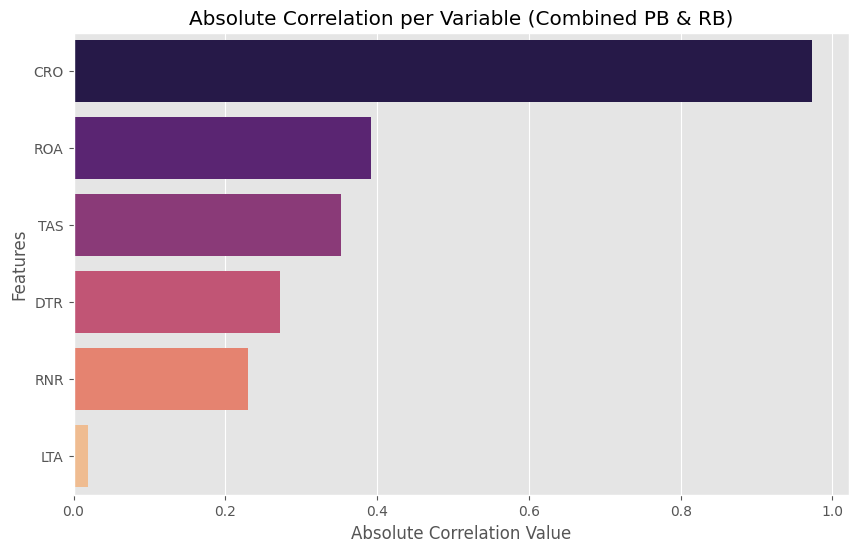

In [17]:
# Menggabungkan hasil korelasi Point-Biserial dan Rank-Biserial
combined_corr_df = pd.concat([pb_df, rb_df], axis=0).reset_index(drop=True)

print("=== HASIL GABUNGAN KORELASI ===")
display(combined_corr_df)

# Visualisasi absolute correlation gabungan
combined_corr_df['Abs_Correlation'] = combined_corr_df['Correlation (r)'].abs()
combined_corr_df = combined_corr_df.sort_values(by='Abs_Correlation', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Abs_Correlation', y='Variable', data=combined_corr_df, palette='magma', hue='Variable', legend=False)

plt.title('Absolute Correlation per Variable (Combined PB & RB)')
plt.xlabel('Absolute Correlation Value')
plt.ylabel('Features')
plt.show()

# Uji Independent T-Test

Independent T-Test untuk mengetahui perbedaan rata-rata dari 2 kelompok pada masing-masing variabel. Pada kasus ini, 2 kelompok tersebut adalah jika FFR atau Y=0 dan Y=1.

* Jika Data Normal dan Homoscedastic, maka pakai Uji Independent T-Test
* Jika Data Normal tapi tidak Homoscedastic, maka pakai Uji Independent T-Test dengan Welch's T-test (`equal_var=False`)
* Jika Data tidak Normal, maka pakai UjI Mann-Whitney

In [18]:
X_ind_ttest = assumption_summary[(assumption_summary['Normal-Final'] == 'Yes') & (assumption_summary['Homoscedastic'] == 'Yes')]['Variable']
X_welch_ttest = assumption_summary[(assumption_summary['Normal-Final'] == 'Yes') & (assumption_summary['Homoscedastic'] == 'No')]['Variable']
X_mann_whitney = assumption_summary[(assumption_summary['Normal-Final'] == 'No')]['Variable']

print(list(X_ind_ttest))
print(list(X_welch_ttest))
print(list(X_mann_whitney))

['DTR', 'LTA']
['TAS']
['ROA', 'CRO', 'RNR']


Untuk membantu perhitungan seberapa berbeda kedua grup atau kelas pada Independent T-Test. Interpretasi Cohens D sebagai berikut:
* 0.2 <= d <= 0.5 berarti efek kecil
* 0.5 < d <= 0.8 berarti efek sedang
* d > 0.8 berarti efek kuat

In [19]:
def calculate_cohens_d(group1, group2):
    """
    Menghitung Effect Size (Cohen's d) untuk Independent T-Test.
    """
    # 1. Hitung jumlah sampel (n)
    n1, n2 = len(group1), len(group2)

    # 2. Hitung rata-rata (mean) dari kedua kelompok
    mean1, mean2 = np.mean(group1), np.mean(group2)

    # 3. Hitung varians sampel (gunakan ddof=1 karena ini adalah data sampel)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # 4. Hitung Pooled Standard Deviation (Standar Deviasi Gabungan)
    # Rumus: akar dari [ ((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2) ]
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    # 5. Hitung Cohen's d
    d = (mean1 - mean2) / pooled_sd

    # Mengembalikan nilai absolut agar fokus pada besaran efeknya (bukan arahnya)
    return abs(d)

## Independent T-Test

In [20]:
# Uji Independent T-test untuk variabel yang lolos asumsi (Normal & Homoscedastic)
t_test_results = []

for col in X_ind_ttest:
    group0 = Kelas0[col]
    group1 = Kelas1[col]

    # Melakukan Independent T-test
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=True)
    d_val = calculate_cohens_d(group0, group1)

    t_test_results.append({
        'Variable': col,
        'T-Statistic': round(t_stat, 4),
        'P-value': round(p_val, 4),
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Cohen\'s d': round(d_val, 2)
    })

t_test_df = pd.DataFrame(t_test_results)
print("=== HASIL INDEPENDENT T-TEST ===")
t_test_df

=== HASIL INDEPENDENT T-TEST ===


,Variable,T-Statistic,P-value,Significant,Cohen's d
0,DTR,3.6575,0.0003,Yes,0.58
1,LTA,-0.2460,0.8060,No,0.04


## Independent T-Test with Welch

In [21]:
welch_t_test_results = []

for col in X_welch_ttest:
    group0 = Kelas0[col]
    group1 = Kelas1[col]

    # Melakukan Independent T-test
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    d_val = calculate_cohens_d(group0, group1)

    welch_t_test_results.append({
        'Variable': col,
        'T-Statistic': round(t_stat, 4),
        'P-value': round(p_val, 4),
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Cohen\'s d': round(d_val, 2)
    })

welch_t_test_df = pd.DataFrame(welch_t_test_results)
print("=== HASIL INDEPENDENT T-TEST Welch ===")
welch_t_test_df

=== HASIL INDEPENDENT T-TEST Welch ===


,Variable,T-Statistic,P-value,Significant,Cohen's d
0,TAS,4.6885,0.0,Yes,0.69


## Mann-Whitney Test

1. Pada Mann-Whitney, untuk mengetahui seberapa besar perbedaan atau pengaruh, bisa menggunakan Korelasi Rank-Biserial, ataupun Eta-Square. Karena Korelasi Rank-Biserial sudah digunakan sebelumnya, maka sekarang pakai Eta Square.
2. Interpretasi Eta Square:
* 0.1 <= e <= 0.3 berarti efek kecil
* 0.3 < e <= 0.5 berarti efek sedang
* e > 0.5 berarti efek kuat

In [22]:
# Uji Mann-Whitney untuk variabel yang tidak normal (X_mann_whitney)
mann_whitney_results = []

for col in X_mann_whitney:
    group0 = Kelas0[col]
    group1 = Kelas1[col]

    # Melakukan Mann-Whitney U Test
    n1, n2 = len(group0), len(group1)
    stat, p_val = stats.mannwhitneyu(group0, group1, alternative='two-sided')

    # Menghitung Eta-Squared (n^2 = Z^2 / (N-1))
    # Menggunakan pendekatan Normal (Z score) untuk Mann-Whitney
    z_score = stats.norm.ppf(p_val/2) if p_val > 0 else 0
    eta_sq = (z_score**2) / (n1 + n2 - 1)

    mann_whitney_results.append({
        'Variable': col,
        'U-Statistic': round(stat, 4),
        'P-value': round(p_val, 4),
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Eta-Square': round(eta_sq, 4)
    })

mann_whitney_df = pd.DataFrame(mann_whitney_results)
print("=== HASIL MANN-WHITNEY TEST ===")
mann_whitney_df

=== HASIL MANN-WHITNEY TEST ===


,Variable,U-Statistic,P-value,Significant,Eta-Square
0,ROA,2076.0,0.0000,Yes,0.1086
1,CRO,94.0,0.0000,Yes,0.6698
2,RNR,2626.0,0.0117,Yes,0.0376


## Efek Gabungan (Interpretasi Final)

In [23]:
# 1. Menyiapkan DataFrame gabungan dengan menyamakan nama kolom effect size
t_test_prep = t_test_df.rename(columns={'Cohen\'s d': 'Value'})
welch_prep = welch_t_test_df.rename(columns={'Cohen\'s d': 'Value'})
mann_prep = mann_whitney_df.rename(columns={'Eta-Square': 'Value'})

# Tambahkan label metode
t_test_prep['Method'] = 'Independent T-Test'
welch_prep['Method'] = 'Welch T-Test'
mann_prep['Method'] = 'Mann-Whitney'

# Gabungkan
combined_diff_df = pd.concat([
    t_test_prep[['Variable', 'Significant', 'Value', 'Method']],
    welch_prep[['Variable', 'Significant', 'Value', 'Method']],
    mann_prep[['Variable', 'Significant', 'Value', 'Method']]
], axis=0).reset_index(drop=True)

# 2. Fungsi Interpretasi dan Scoring
def categorize_effect(row):
    val = row['Value']
    method = row['Method']

    if method in ['Independent T-Test', 'Welch T-Test']:
        # Cohen's d criteria
        if val < 0.2: return 'Sangat Kecil', 0
        elif 0.2 <= val <= 0.5: return 'Kecil', 1
        elif 0.5 < val <= 0.8: return 'Sedang', 2
        else: return 'Besar', 3
    else:
        # Eta Square criteria
        if val < 0.1: return 'Sangat Kecil', 0
        elif 0.1 <= val <= 0.3: return 'Kecil', 1
        elif 0.3 < val <= 0.5: return 'Sedang', 2
        else: return 'Besar', 3

# Terapkan fungsi
results = combined_diff_df.apply(categorize_effect, axis=1)
combined_diff_df['Effect Interpretation'] = [r[0] for r in results]
combined_diff_df['Effect Score'] = [r[1] for r in results]

print("=== RINGKASAN GABUNGAN UJI PERBEDAAN (FINAL) ===")
combined_diff_df.sort_values(by='Effect Score', ascending=False)

=== RINGKASAN GABUNGAN UJI PERBEDAAN (FINAL) ===


,Variable,Significant,Value,Method,Effect Interpretation,Effect Score
4,CRO,Yes,0.6698,Mann-Whitney,Besar,3
0,DTR,Yes,0.5800,Independent T-Test,Sedang,2
2,TAS,Yes,0.6900,Welch T-Test,Sedang,2
3,ROA,Yes,0.1086,Mann-Whitney,Kecil,1
1,LTA,No,0.0400,Independent T-Test,Sangat Kecil,0
5,RNR,Yes,0.0376,Mann-Whitney,Sangat Kecil,0


# Random Forest

Salah satu Ensemble Method yang baik untuk klasifikasi dan juga bisa untuk mencari variabel berpengaruh.

In [24]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, Y)

RandomForestClassifier(random_state=42)

## Feature Importance

Fungsi bawaan dari Ensemble Model Random Forest. Menghitung variabel berpengaruh untuk semua pohon menggunakan Gini Impurity

/tmp/ipykernel_1356/3177398027.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


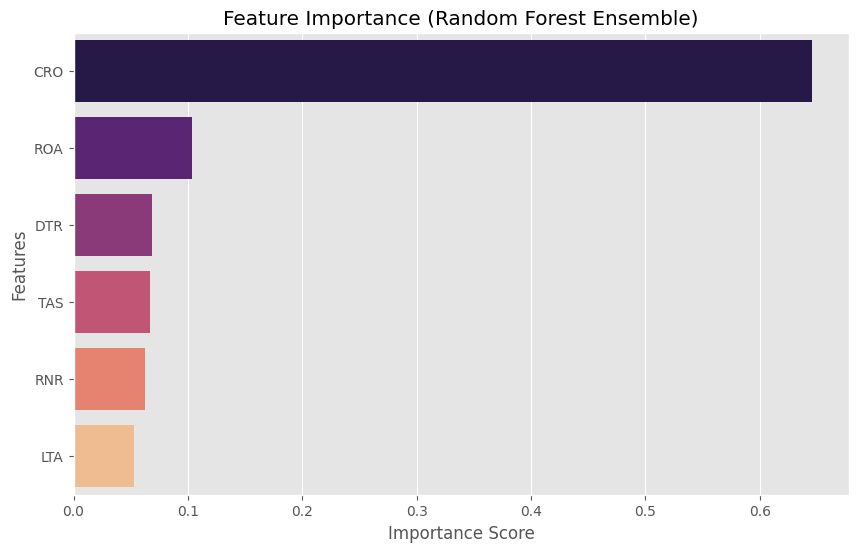

In [25]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance (Random Forest Ensemble)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## SHAP

Feature Importance hanya melihat variabel mana saja yang penting dan angka importance-nya. Tapi tidak tahu kenapa dan ke mana arahnya. Untuk itu digunakan SHAP untuk visualisasi.

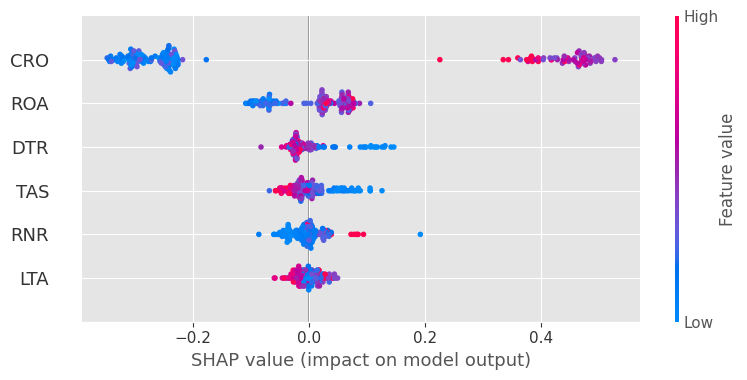

In [26]:
# Create SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the features X
shap_values = explainer.shap_values(X)

# Visualize the feature importance and impact using a summary plot
# For binary classification, we usually plot the SHAP values for the positive class (index 1)
shap.summary_plot(shap_values[:, :, 1], X)

Cara membaca SHAP:
* Sumbu Y menunjukan kepentingan fitur (feature importance) yang sudah diurutkan dari teratas adalah yang terpenting dan terbawah adalah yang paling tidak penting. CRO adalah yang terpenting.
* Sumbu X menunjukan arah dampak. Ke kanan (>0) artinya mendorong prediksi ke kelas FFR 1, dan ke kiri (< 0) artinya mendorong prediksi ke kelas FFR 0
* Titik merah adalah nilai tinggi, dan titik biru adalah nilai rendah. Jika banyak biru di kiri dan merah di kanan (CRO, ROA, RNR), berarti jika nilai variabel rendah, maka cenderung ke Kelas 0 (FFR = 0). Jika sebaliknya, banyak biru di kanan dan merah di kiri (DTR, TAS), berarti jika nilai variabel rendah, maka cenderung ke Kelas 1 (FFR = 1). LTA sangat bercampur sehingga tidak bisa digunakan.

## Permutation Importance

Sebaiknya dilakukan jika data tidak Multikolinear (X tidak berkorelasi kuat satu sama lain). Karena kita sudah Uji Multikolinearitas sebelumnya dan lolos semua, maka kita bisa lanjutkan.

Di sini sebaiknya menggunakan data train karena merupakan best practice agar data tidak overfit

In [27]:
rf_model_train = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_train.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Permutation Importance menghitung seberapa turunnya performa model jika 1 variabel posisinya diacak-acak. Jika performanya langsung turun, berarti variabel tersebut penting. Jika walaupun sudah diacak performanya tidak turun, berarti variabel tersebut tidak penting.

In [28]:
# 4. Hitung Permutation Importance pada Data Test
# n_repeats adalah berapa kali variabel diacak untuk mendapat rata-rata yang stabil
result = permutation_importance(rf_model_train, X_test, y_test, n_repeats=12, random_state=42)

In [29]:
# 5. Organisasi Hasil ke DataFrame agar mudah dibaca
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print("Top 10 Variabel Paling Berpengaruh:")
importance_df

Top 10 Variabel Paling Berpengaruh:


,Feature,Importance_Mean,Importance_Std
2,CRO,0.485294,0.064101
0,ROA,0.000000,0.000000
1,TAS,0.000000,0.000000
3,DTR,0.000000,0.000000
4,RNR,0.000000,0.000000
5,LTA,0.000000,0.000000


## Recursive Feature Elimination (RFE)

RFE melakukan pelatihan model secara bertahap. Langkah pertama yaitu dengan memasukan seluruh variabel. Lalu setelah itu variabel yang tidak penting akan dieliminasi. Lalu dilanjutkan dengan variabel tersisa dan eliminasi lagi. Sampai ke banyaknya fitur ke-n (ditentukan user).

In [30]:
rfecv = RFECV(estimator=rf_model, step=1, cv=5)
rfecv.fit(X, Y)
print(f"Jumlah fitur optimal: {rfecv.n_features_}")

Jumlah fitur optimal: 2


RFE Cross Validation untuk membantu mencari berapa jumlah fitur optimal. Jadi tidak perlu menebak-nebak kira-kira butuh berapa secara manual

In [31]:
# Memilih 5 fitur terbaik
rfe = RFE(estimator=rf_model, n_features_to_select=rfecv.n_features_)
X_rfe = rfe.fit_transform(X, Y)

In [32]:
# 3. Hasil Seleksi
df_rfe = pd.DataFrame({
    'Fitur': X.columns,
    'Terpilih': rfe.support_,
    'Ranking': rfe.ranking_
})

df_rfe.sort_values(by='Ranking')

,Fitur,Terpilih,Ranking
0,ROA,True,1
2,CRO,True,1
3,DTR,False,2
4,RNR,False,3
1,TAS,False,4
5,LTA,False,5


> Perlu diingat bahwa nilai Feature Importance (yang didapatkan dari sebelumnya) yang dipakai untuk eliminasi. RFE lebih berfokus ke hasil akhir dan juga urutan siapa yang dieliminasi terlebih dahulu.

# XGBoost

Salah satu Ensemble Method Boosting yang baik untuk klasifikasi dan juga bisa untuk mencari variabel berpengaruh.

Untuk penjelasan lebih detail, bisa dilihat di Random Forest karena langkah-langkah yang dilakukan sama.

In [33]:
# Initialize and fit the XGBoost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X, Y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## Feature Importance

XGBoost bisa memiliki tipe feature importance yang lebih bermacam-macam

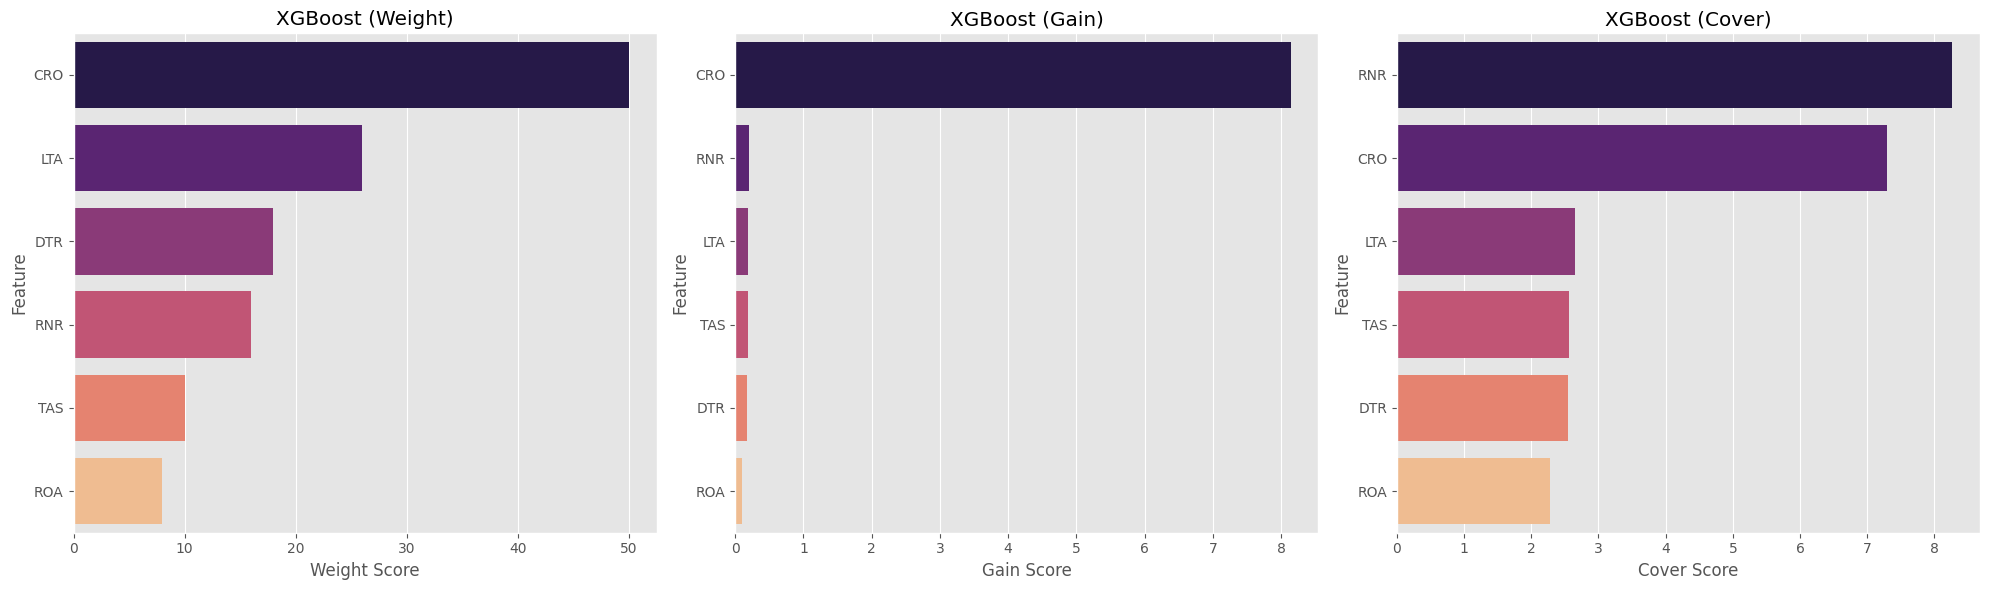

In [34]:
# Define the importance types to visualize
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, len(importance_types), figsize=(20, 6))

for i, imp_type in enumerate(importance_types):
    score_dict = xgb_model.get_booster().get_score(importance_type=imp_type)
    feat_map = {f'f{idx}': col for idx, col in enumerate(X.columns)}
    mapped_scores = {feat_map.get(k, k): v for k, v in score_dict.items()}
    df_imp = pd.DataFrame({'Feature': mapped_scores.keys(), 'Importance': mapped_scores.values()})
    df_imp = df_imp.sort_values(by='Importance', ascending=False)
    sns.barplot(x='Importance', y='Feature', data=df_imp, palette='magma', ax=axes[i], hue='Feature', legend=False)
    axes[i].set_title(f'XGBoost ({imp_type.capitalize()})')
    axes[i].set_xlabel(f'{imp_type.capitalize()} Score')

plt.tight_layout()
plt.show()

## SHAP

Perlu diingat bahwa urutan variabel SHAP bisa berbeda dari Feature Importance, karena keduanya menghitung hal yang berbeda

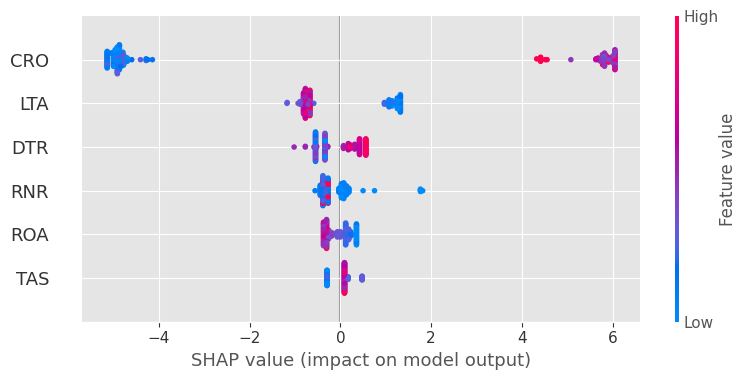

In [35]:
# Create SHAP explainer for XGBoost using TreeExplainer
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X)

# Visualize SHAP summary plot
shap.summary_plot(shap_values_xgb, X)

## Permutation Importance

Perlu diingat lagi bahwa sebaiknya Cek Multikolinearitas jika belum.

In [36]:
# Fit model on training data
xgb_model_train = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model_train.fit(X_train, y_train)

# Calculate Permutation Importance
result_xgb = permutation_importance(xgb_model_train, X_test, y_test, n_repeats=12, random_state=42)

# Organize results
importance_xgb_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': result_xgb.importances_mean,
    'Importance_Std': result_xgb.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print("Top Variabel XGBoost (Permutation Importance):")
display(importance_xgb_df)

Top Variabel XGBoost (Permutation Importance):


,Feature,Importance_Mean,Importance_Std
2,CRO,0.485294,0.064101
0,ROA,0.000000,0.000000
1,TAS,0.000000,0.000000
3,DTR,0.000000,0.000000
4,RNR,0.000000,0.000000
5,LTA,0.000000,0.000000


## RFE

In [37]:
# RFECV for XGBoost
rfecv_xgb = RFECV(estimator=xgb_model, step=1, cv=5)
rfecv_xgb.fit(X, Y)
print(f"Jumlah fitur optimal XGBoost: {rfecv_xgb.n_features_}")

Jumlah fitur optimal XGBoost: 1


In [39]:
# RFE Selection
rfe_xgb = RFE(estimator=xgb_model, n_features_to_select=rfecv_xgb.n_features_)
rfe_xgb.fit(X, Y)

# Organize results
df_rfe_xgb = pd.DataFrame({
    'Fitur': X.columns,
    'Terpilih': rfe_xgb.support_,
    'Ranking': rfe_xgb.ranking_
})

df_rfe_xgb.sort_values(by='Ranking')

,Fitur,Terpilih,Ranking
2,CRO,True,1
5,LTA,False,2
1,TAS,False,3
4,RNR,False,4
3,DTR,False,5
0,ROA,False,6


# Regresi Logistik LASSO (L1 Regularization)

Menggunakan Regresi Logistik juga, tapi pakai L1. Ini dimaksudkan untuk memberikan "pinalti" kepada variabel yang tidak berpengaruh menjadi koefisien 0.

Untuk LASSO, wajib Standarisasi Data (Z-Score)

In [40]:
# 2. Standardisasi Data (WAJIB untuk LASSO)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Menggunakan Regresi Logistic Cross Validation, karena lebih baik untuk mencari variabel yang penting

In [41]:
# 3. Model Logistic Regression dengan Penalti L1 (LASSO)
# Cs adalah jumlah kandidat nilai regularisasi yang akan dicoba (tuning)
# cv=5 berarti menggunakan 5-fold cross-validation
lasso_logit = LogisticRegressionCV(
    penalty='l1',
    solver='liblinear',
    cv=5,
    random_state=42,
    max_iter=10000
)

lasso_logit.fit(X_scaled, Y)

LogisticRegressionCV(cv=5, max_iter=10000, penalty='l1', random_state=42,
                     solver='liblinear')

In [42]:
# 4. Melihat Koefisien Hasil LASSO
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_logit.coef_[0]
})

print("Hasil Koefisien LASSO:")
coef_df

Hasil Koefisien LASSO:


,Feature,Coefficient
0,ROA,0.000000
1,TAS,0.000000
2,CRO,1.437578
3,DTR,0.000000
4,RNR,0.000000
5,LTA,0.000000


In [43]:
# 5. Interpretasi
significant_features = coef_df[coef_df['Coefficient'] != 0]
print("\nVariabel yang terpilih (koefisien tidak nol):")
significant_features


Variabel yang terpilih (koefisien tidak nol):


,Feature,Coefficient
2,CRO,1.437578


In [44]:
print(f"\nParameter C terbaik: {lasso_logit.C_[0]}")


Parameter C terbaik: 0.046415888336127774


# SelectKBest

Ini adalah kasus klasifikasi karena variabel Y adalah 1 dan 0. SelectKBest yang digunakan adalah ANOVA (`f_classif`) dan Mutual Information (`mutual_info_classif`). Chi tidak digunakan karena data X ada yang bernilai negatif.

## ANOVA

Untuk melihat hubungan linear

=== HASIL SELECT K BEST (f_classif) ===


,Feature,F-Score,P-Value,Significant
2,CRO,187.151399,4.137409e-29,Yes
1,TAS,19.138829,2.127514e-05,Yes
3,DTR,13.377320,3.404862e-04,Yes
4,RNR,6.588167,1.113824e-02,Yes
0,ROA,6.079045,1.468434e-02,Yes
5,LTA,0.060491,8.060211e-01,No


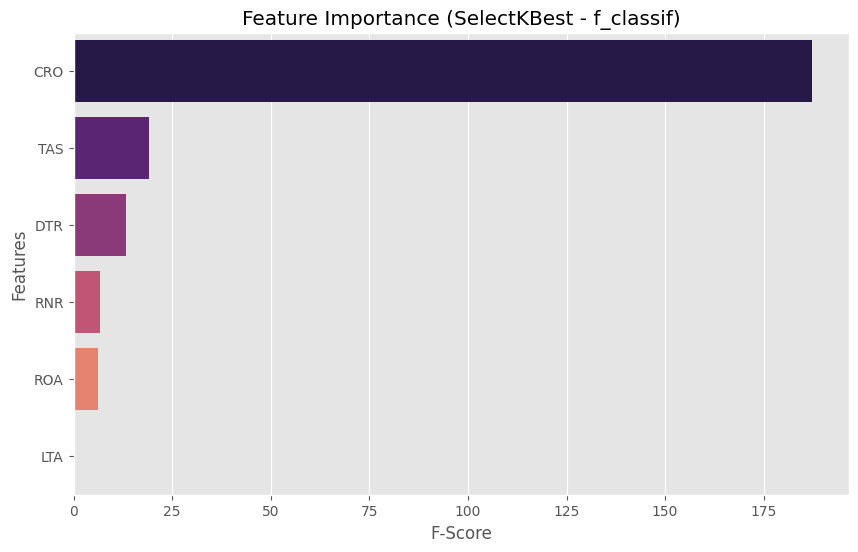

In [45]:
# Memilih semua fitur untuk melihat skor f_classif masing-masing
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, Y)

# Menampilkan hasil skor
skbest_results = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_,
    'Significant': ['Yes' if p < 0.05 else 'No' for p in selector.pvalues_]
}).sort_values(by='F-Score', ascending=False)

print("=== HASIL SELECT K BEST (f_classif) ===")
display(skbest_results)

# Visualisasi skor
plt.figure(figsize=(10, 6))
sns.barplot(x='F-Score', y='Feature', data=skbest_results, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance (SelectKBest - f_classif)')
plt.xlabel('F-Score')
plt.ylabel('Features')
plt.show()

## Mutual Information

Lebih baik untuk melihat hubungan kompleks yang tidak linear. Dengan menggunakan Entropy pada KNN (K-Nearest Neighbour)

=== HASIL SELECT K BEST (mutual_info_classif) ===


,Feature,Mutual-Info-Score
2,CRO,0.603422
5,LTA,0.179277
1,TAS,0.095873
3,DTR,0.089607
4,RNR,0.069155
0,ROA,0.057742


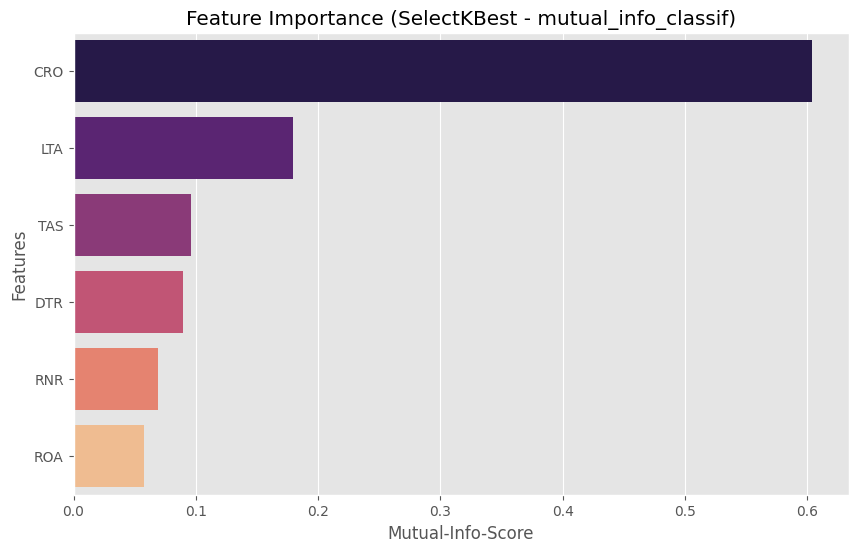

In [46]:
# Memilih semua fitur untuk melihat skor mutual_info_classif masing-masing
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X, Y)

# Menampilkan hasil skor
skbest_results = pd.DataFrame({
    'Feature': X.columns,
    'Mutual-Info-Score': selector.scores_
}).sort_values(by='Mutual-Info-Score', ascending=False)

print("=== HASIL SELECT K BEST (mutual_info_classif) ===")
display(skbest_results)

# Visualisasi skor
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual-Info-Score', y='Feature', data=skbest_results, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance (SelectKBest - mutual_info_classif)')
plt.xlabel('Mutual-Info-Score')
plt.ylabel('Features')
plt.show()

# Kesimpulan

* Dari seluruh metode yang dilakukan dalam mencari variabel berpengaruh, atau kasusnya di sini adalah faktor yang menentukan fleksibilitas keuangan (FFR), faktor yang paling berpengaruh adalah Cash Holding (CRO) yang hampir seluruh metode menempatkan CRO sebagai yang paling berpengaruh, atau bahkan satu-satunya yang memiliki pengaruh.
* Retained Earnings (RNR) memiliki performa yang naik turun dan tidak tetap jika dicari menggunakan metode selain Regresi Logistik. Jadi walaupun RNR signifikan dan memiliki pengaruh yang baik di regresi logistik, namun pada metode lain RNR sering kali tidak bisa menjadi faktor penentu (berpengaruh)
* Untuk itu, faktor atau variabel yang akan digunakan ke dalam model prediksi adalah CRO.